In [4]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

tf.keras.backend.clear_session()

In [5]:
IMG_SIZE = 96
BATCH_SIZE = 32
CLASSES = ['surprise', 'happy', 'sad']
NUM_CLASSES = len(CLASSES)
DATA_DIR = 'emotion_dataset/'
MODEL_DIR = 'generated_mobilenet/'
ALPHA = 0.5
HEAD_EPOCHS = 30
FINETUNE_EPOCHS = 50
HEAD_LR = 1e-3
FINETUNE_LR = 1e-5
FINE_TUNE_AT = 151
SAVE_ARTIFACTS = True

In [6]:
if SAVE_ARTIFACTS:
    os.makedirs(MODEL_DIR, exist_ok=True)

print({
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'classes': CLASSES,
    'model_dir': MODEL_DIR,
    'alpha': ALPHA,
    'head_epochs': HEAD_EPOCHS,
    'finetune_epochs': FINETUNE_EPOCHS,
})

{'img_size': 96, 'batch_size': 32, 'classes': ['surprise', 'happy', 'sad'], 'model_dir': 'generated_mobilenet/', 'alpha': 0.5, 'head_epochs': 30, 'finetune_epochs': 50}


In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_names=CLASSES,
    shuffle=True,
    seed=42,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'val'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_names=CLASSES,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_names=CLASSES,
    shuffle=False,
)

Found 12600 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Found 900 files belonging to 3 classes.


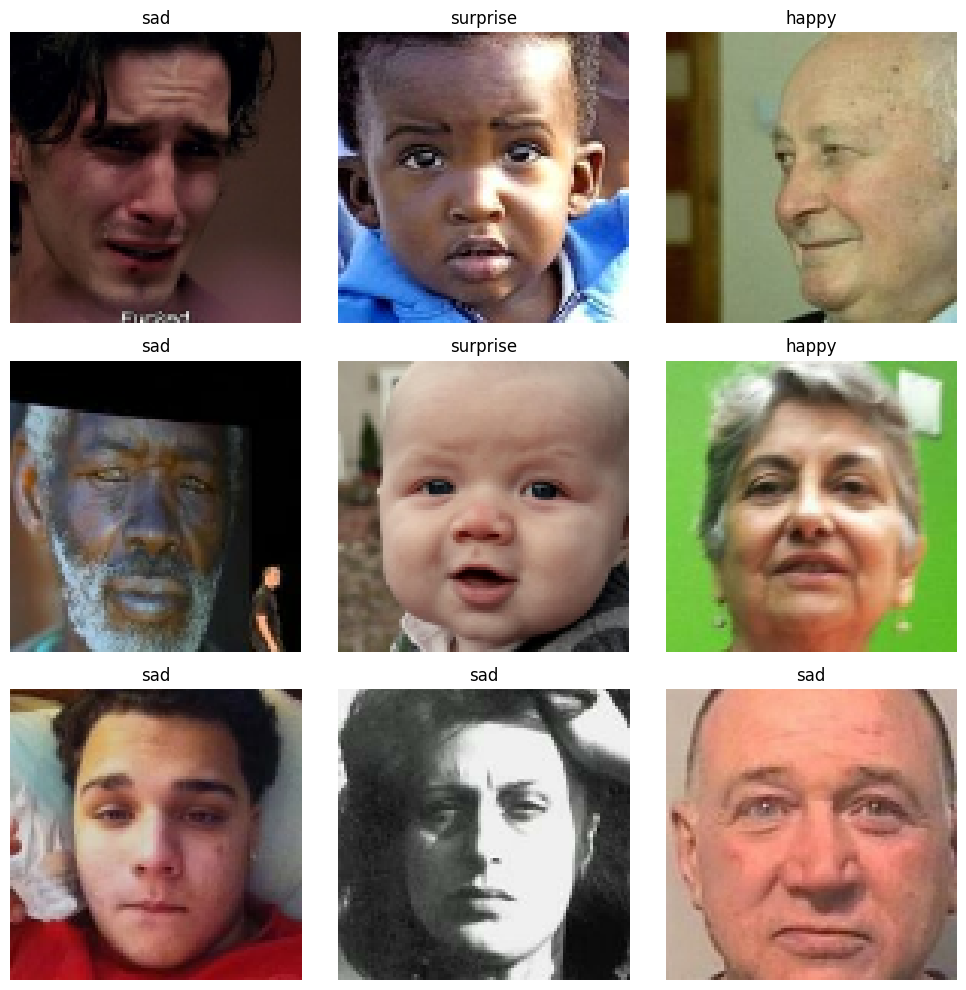

In [8]:
images, labels = next(iter(train_ds))
plt.figure(figsize=(10, 10))
for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(CLASSES[labels[i].numpy()])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [10]:
def build_mobilenet(input_size, num_classes, alpha=0.5, dropout_rate=0.3):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(input_size, input_size, 3),
        include_top=False,
        weights='imagenet',
        alpha=alpha,
        name='mobilenetv2_backbone',
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(input_size, input_size, 3))
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.Conv2D(64, 1, padding='same', activation='relu')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)


    model = tf.keras.Model(inputs, outputs)
    return model, base_model

In [11]:
model, base_model = build_mobilenet(IMG_SIZE, NUM_CLASSES, ALPHA)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_backbone            │ (None, 3, 3, 1280)     │       706,224 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 3, 3, 64)       │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 788,403 (3.01 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 706,224 (2.69 MB)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=HEAD_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

head_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6),
]

if SAVE_ARTIFACTS:
    head_callbacks.append(
        tf.keras.callbacks.ModelCheckpoint(
            os.path.join(MODEL_DIR, 'head.keras'),
            save_best_only=True,
        )
    )

In [13]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    callbacks=head_callbacks,
)

Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.5691 - loss: 0.9096 - val_accuracy: 0.5567 - val_loss: 0.9372 - learning_rate: 0.0010
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.6844 - loss: 0.7310 - val_accuracy: 0.5978 - val_loss: 0.9193 - learning_rate: 0.0010
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.7466 - loss: 0.6112 - val_accuracy: 0.6000 - val_loss: 0.9601 - learning_rate: 0.0010
Epoch 4/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.7912 - loss: 0.5179 - val_accuracy: 0.6011 - val_loss: 1.0166 - learning_rate: 0.0010
Epoch 5/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.8310 - loss: 0.4323 - val_accuracy: 0.5978 - val_loss: 1.0604 - learning_rate: 0.0010
Epoch 6/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8671 - loss: 0.3497 - val_accuracy: 0.5933 - val_loss: 1.1124 - learning_rate: 5.0000e-04
Epoch 7/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.8894

In [14]:
if SAVE_ARTIFACTS and os.path.exists(os.path.join(MODEL_DIR, 'head.keras')):
    model = tf.keras.models.load_model(os.path.join(MODEL_DIR, 'head.keras'))

base_model = model.get_layer('mobilenetv2_backbone')

In [15]:
y_pred = np.argmax(model.predict(test_ds), axis=1)
y_true = np.concatenate([y for _, y in test_ds])

print(classification_report(y_true, y_pred, target_names=CLASSES))

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step
              precision    recall  f1-score   support

    surprise       0.58      0.57      0.58       300
       happy       0.65      0.74      0.69       300
         sad       0.58      0.51      0.54       300

    accuracy                           0.61       900
   macro avg       0.60      0.61      0.60       900
weighted avg       0.60      0.61      0.60       900



2026-04-23 18:30:45.978044: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


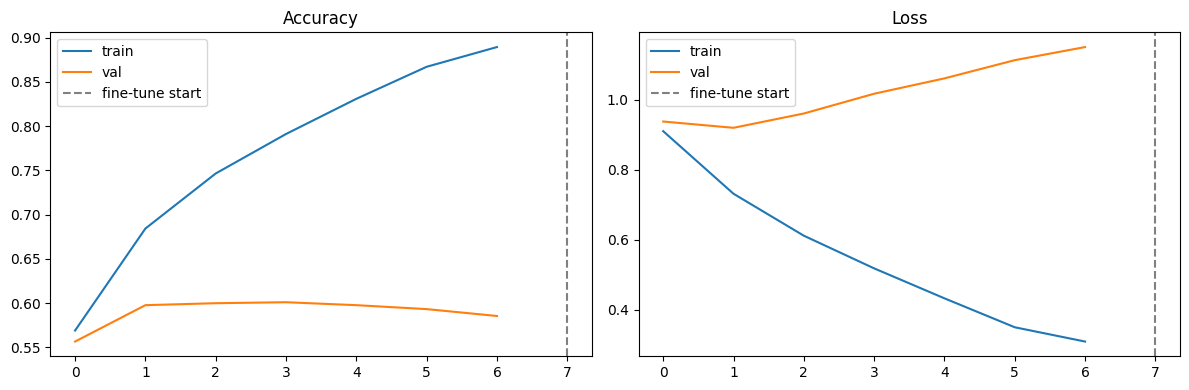

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

all_acc = history_head.history['accuracy']
all_val_acc = history_head.history['val_accuracy']
all_loss = history_head.history['loss']
all_val_loss = history_head.history['val_loss']

axes[0].plot(all_acc, label='train')
axes[0].plot(all_val_acc, label='val')
axes[0].axvline(
    x=len(history_head.history['accuracy']),
    color='gray',
    linestyle='--',
    label='fine-tune start',
)
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(all_loss, label='train')
axes[1].plot(all_val_loss, label='val')
axes[1].axvline(
    x=len(history_head.history['loss']),
    color='gray',
    linestyle='--',
    label='fine-tune start',
)
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig('mobilenet_curves.png')

plt.show()

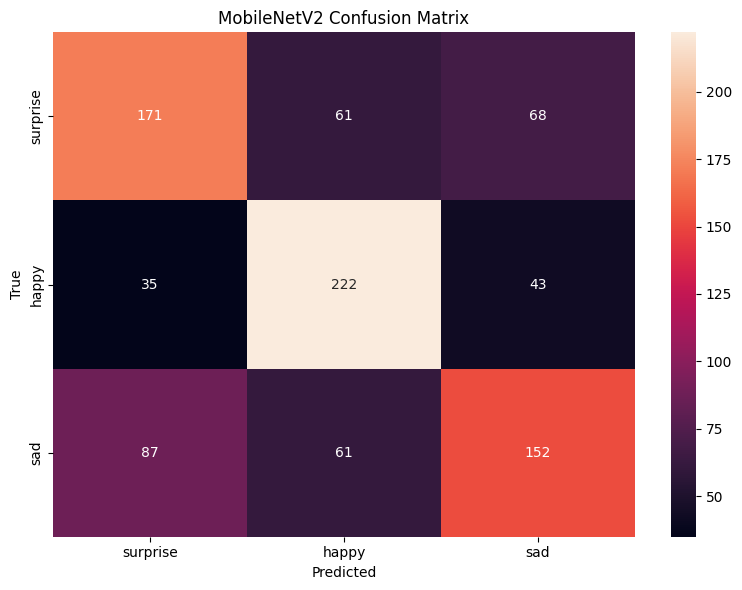

In [18]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('MobileNetV2 Confusion Matrix')
plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig('mobilenet_confusion.png')

plt.show()